In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Load the dataset (make sure the path matches where you saved it)
df = pd.read_excel('data/online_retail_II.xlsx', sheet_name='Year 2010-2011')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/online_retail_II.xlsx'

In [ ]:
# Check column names and data types
print("Column Info:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

In [4]:
import os

# This shows your current working directory
print("Current folder:", os.getcwd())

# This lists everything in your current folder
print("\nFiles here:")
for item in os.listdir():
    print(item)
    

Current folder: C:\Users\DELL\CustomerSegmentation-RFM

Files here:
.ipynb_checkpoints
data
rfm_analysis.ipynb


In [5]:
# File is CSV not Excel - use read_csv instead
df = pd.read_csv('data/online_retail_II.csv', encoding='unicode_escape')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()


Dataset shape: (1067371, 8)
Rows: 1,067,371 | Columns: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
print("Column Info:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Column Info:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

Missing Values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [7]:
df = df.dropna(subset=['Customer ID'])
print(f"After removing null CustomerIDs: {df.shape[0]:,} rows")

df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"After removing cancellations: {df.shape[0]:,} rows")

df = df[df['Quantity'] > 0]
print(f"After removing invalid quantities: {df.shape[0]:,} rows")

df = df[df['Price'] > 0]
print(f"After removing invalid prices: {df.shape[0]:,} rows")

After removing null CustomerIDs: 824,364 rows
After removing cancellations: 805,620 rows
After removing invalid quantities: 805,620 rows
After removing invalid prices: 805,549 rows


In [8]:
df['TotalRevenue'] = df['Quantity'] * df['Price']

print("TotalRevenue column created!")
df[['Invoice', 'Customer ID', 'Quantity', 'Price', 'TotalRevenue']].head(10)

TotalRevenue column created!


,Invoice,Customer ID,Quantity,Price,TotalRevenue
0,489434,13085.0,12,6.95,83.4
1,489434,13085.0,12,6.75,81.0
2,489434,13085.0,12,6.75,81.0
3,489434,13085.0,48,2.10,100.8
4,489434,13085.0,24,1.25,30.0
5,489434,13085.0,24,1.65,39.6
6,489434,13085.0,24,1.25,30.0
7,489434,13085.0,10,5.95,59.5
8,489435,13085.0,12,2.55,30.6
9,489435,13085.0,12,3.75,45.0


In [9]:
# Convert InvoiceDate to datetime first
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("=== CLEAN DATASET SUMMARY ===")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Unique Customers: {df['Customer ID'].nunique():,}")
print(f"Unique Products: {df['StockCode'].nunique():,}")
print(f"Date Range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Total Revenue: £{df['TotalRevenue'].sum():,.2f}")

=== CLEAN DATASET SUMMARY ===
Total Rows: 805,549
Unique Customers: 5,878
Unique Products: 4,631
Date Range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Total Revenue: £17,743,429.18


In [10]:
import datetime as dt

# Set reference date (1 day after last transaction)
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

# Build RFM table
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalRevenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(f"\nRFM Table created for {rfm.shape[0]:,} customers")
print(rfm.head(10))

Snapshot date: 2011-12-10 12:50:00

RFM Table created for 5,878 customers
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326         12  77556.46
1     12347.0        2          8   5633.32
2     12348.0       75          5   2019.40
3     12349.0       19          4   4428.69
4     12350.0      310          1    334.40
5     12351.0      375          1    300.93
6     12352.0       36         10   2849.84
7     12353.0      204          2    406.76
8     12354.0      232          1   1079.40
9     12355.0      214          2    947.61


In [11]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("Scores assigned!")
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))

Scores assigned!
   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0     12346.0      326         12  77556.46       2       5       5       255
1     12347.0        2          8   5633.32       5       4       5       545
2     12348.0       75          5   2019.40       3       4       4       344
3     12349.0       19          4   4428.69       5       3       5       535
4     12350.0      310          1    334.40       2       1       2       212
5     12351.0      375          1    300.93       2       1       2       212
6     12352.0       36         10   2849.84       4       5       4       454
7     12353.0      204          2    406.76       2       2       2       222
8     12354.0      232          1   1079.40       2       1       3       213
9     12355.0      214          2    947.61       2       2       3       223


In [12]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])

    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Potential Loyalists'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print("=== SEGMENT DISTRIBUTION ===")
print(rfm['Segment'].value_counts())

=== SEGMENT DISTRIBUTION ===
Segment
Lost Customers         1523
Champions              1482
Loyal Customers        1221
At Risk                 824
New Customers           443
Potential Loyalists     385
Name: count, dtype: int64


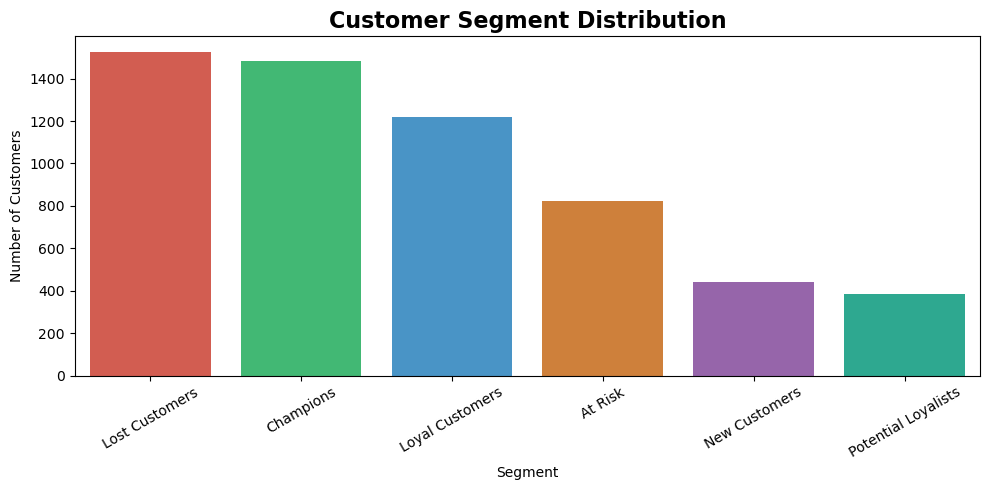

Chart saved!


In [13]:
plt.figure(figsize=(10,5))
segment_order = rfm['Segment'].value_counts().index
colors = ['#e74c3c','#2ecc71','#3498db','#e67e22','#9b59b6','#1abc9c']

sns.countplot(data=rfm, x='Segment', order=segment_order, palette=colors)
plt.title('Customer Segment Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

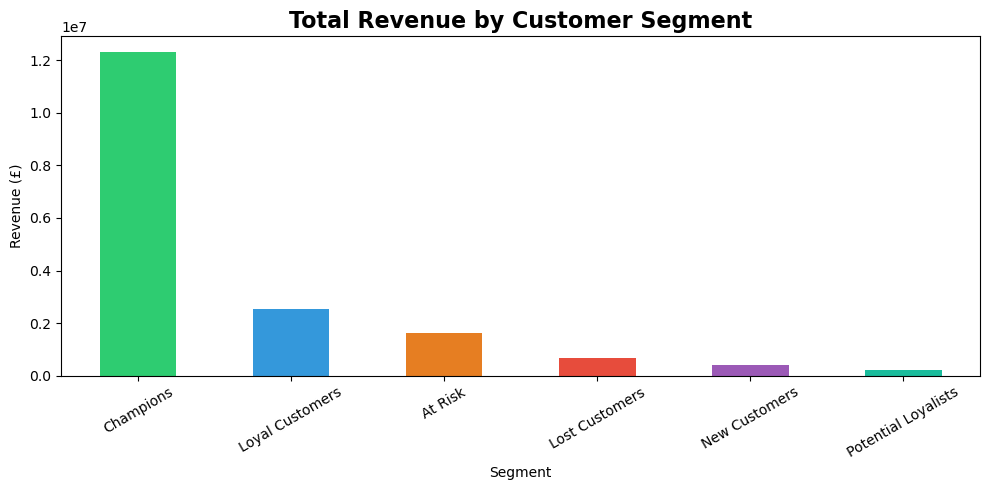

Chart saved!


In [14]:
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
revenue_by_segment.plot(kind='bar', color=['#2ecc71','#3498db','#e67e22','#e74c3c','#9b59b6','#1abc9c'])
plt.title('Total Revenue by Customer Segment', fontsize=16, fontweight='bold')
plt.ylabel('Revenue (£)')
plt.xlabel('Segment')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('revenue_by_segment.png', dpi=150)
plt.show()
print("Chart saved!")

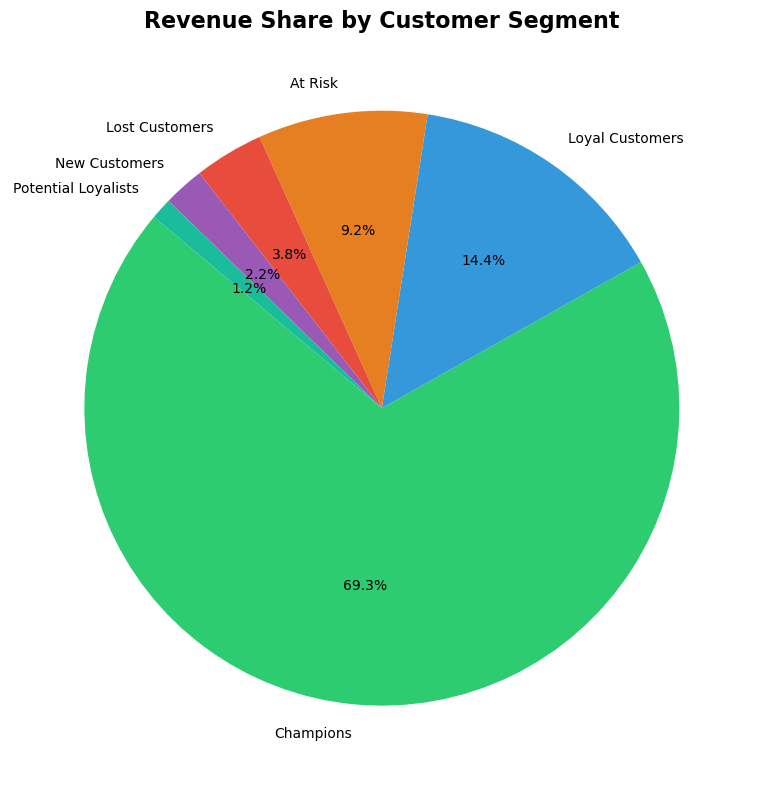

Pie chart saved!


In [15]:
revenue_pct = rfm.groupby('Segment')['Monetary'].sum()
revenue_pct_pct = (revenue_pct / revenue_pct.sum() * 100).sort_values(ascending=False)

plt.figure(figsize=(8,8))
plt.pie(revenue_pct_pct, 
        labels=revenue_pct_pct.index, 
        autopct='%1.1f%%',
        colors=['#2ecc71','#3498db','#e67e22','#e74c3c','#9b59b6','#1abc9c'],
        startangle=140)
plt.title('Revenue Share by Customer Segment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('revenue_share_pie.png', dpi=150)
plt.show()
print("Pie chart saved!")

In [16]:
champions = rfm[rfm['Segment'] == 'Champions']
at_risk = rfm[rfm['Segment'] == 'At Risk']
lost = rfm[rfm['Segment'] == 'Lost Customers']
total_revenue = rfm['Monetary'].sum()

print("=" * 50)
print("       BUSINESS INSIGHTS SUMMARY")
print("=" * 50)

print(f"\n1. Champions ({len(champions)} customers) generate")
print(f"   £{champions['Monetary'].sum():,.0f} = {champions['Monetary'].sum()/total_revenue*100:.1f}% of total revenue")

print(f"\n2. At Risk ({len(at_risk)} customers) still hold")
print(f"   £{at_risk['Monetary'].sum():,.0f} in revenue — urgent retention needed")

print(f"\n3. Lost Customers = {len(lost)} customers ({len(lost)/len(rfm)*100:.1f}% of base)")
print(f"   Only £{lost['Monetary'].sum():,.0f} recovered — re-acquisition costly")

print(f"\n4. Top 25% of customers drive")
print(f"   {champions['Monetary'].sum()/total_revenue*100:.0f}%+ of revenue (80/20 rule confirmed)")

print("\n" + "=" * 50)
print("RECOMMENDATIONS:")
print("=" * 50)
print("→ Protect Champions with loyalty rewards & VIP perks")
print("→ Launch win-back campaign for At Risk segment")
print("→ Upsell Potential Loyalists to increase order value")
print("→ Investigate why 26% customers became Lost")

       BUSINESS INSIGHTS SUMMARY

1. Champions (1482 customers) generate
   £12,293,139 = 69.3% of total revenue

2. At Risk (824 customers) still hold
   £1,633,975 in revenue — urgent retention needed

3. Lost Customers = 1523 customers (25.9% of base)
   Only £667,122 recovered — re-acquisition costly

4. Top 25% of customers drive
   69%+ of revenue (80/20 rule confirmed)

RECOMMENDATIONS:
→ Protect Champions with loyalty rewards & VIP perks
→ Launch win-back campaign for At Risk segment
→ Upsell Potential Loyalists to increase order value
→ Investigate why 26% customers became Lost
